In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures  # l'outil qui prépare les données pour une régression polynomiale
from sklearn.metrics import mean_squared_error, r2_score

# Chargement des données
df = pd.read_csv('social_media_productivity_6000.csv')

# Nettoyage rapide (suppression des lignes avec des valeurs manquantes)
df = df.dropna()

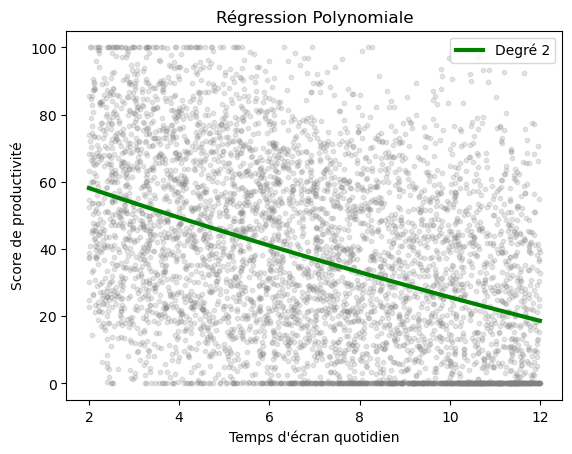

R² Score (Polynomial): 0.1677


In [3]:
# On utilise daily_screen_time pour voir s'il y a un effet de courbure
X_poly_raw = df[['daily_screen_time']].values
y = df['productivity_score'].values

# Transformation polynomiale (degré 2)
poly = PolynomialFeatures(degree=2)#  Le paramètre (degree=2)indique que vous voulez créer des relations au carré ($x^2$).
X_poly = poly.fit_transform(X_poly_raw)# Cette ligne transforme vos données brutes en une nouvelle matrice plus large.

# Entraînement sur les données transformées
model_poly = LinearRegression() # model_poly détecter si la productivité augmente de moins en moins vite avec le temps
model_poly.fit(X_poly, y)

# Visualisation (tri des valeurs pour une courbe fluide)
X_range = np.linspace(X_poly_raw.min(), X_poly_raw.max(), 100).reshape(-1, 1)
y_range_pred = model_poly.predict(poly.transform(X_range))

plt.scatter(X_poly_raw, y, color='gray', alpha=0.2, s=10)
plt.plot(X_range, y_range_pred, color='green', label='Degré 2', linewidth=3)
plt.xlabel('Temps d\'écran quotidien')
plt.ylabel('Score de productivité')
plt.title('Régression Polynomiale')
plt.legend()
plt.show()

print(f"R² Score (Polynomial): {r2_score(y, model_poly.predict(X_poly)):.4f}")